# Считывание Данных

In [2]:
import pandas as pd 
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import numpy as np
import warnings
from datetime import datetime
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import optuna.visualization as vis
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
import kagglehub

path = kagglehub.dataset_download("shuhengmo/uber-nyc-forhire-vehicles-trip-data-2021")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shuhengmo/uber-nyc-forhire-vehicles-trip-data-2021


In [3]:
drive_files = path + '/*.parquet'
drives_needed_cols = ["request_datetime", "PULocationID"]
drives = pl.scan_parquet(drive_files).select([pl.col(x) for x in drives_needed_cols])
print(drives.head(5).collect())

shape: (5, 2)
┌─────────────────────┬──────────────┐
│ request_datetime    ┆ PULocationID │
│ ---                 ┆ ---          │
│ datetime[ns]        ┆ i64          │
╞═════════════════════╪══════════════╡
│ 2021-01-01 00:28:09 ┆ 230          │
│ 2021-01-01 00:45:56 ┆ 152          │
│ 2021-01-01 00:21:15 ┆ 233          │
│ 2021-01-01 00:39:12 ┆ 142          │
│ 2021-01-01 00:46:11 ┆ 143          │
└─────────────────────┴──────────────┘


In [4]:
meteodata_files = path + '/nyc 2021-01-01 to 2021-12-31.csv'
meteo_needed_cols = [
    'datetime', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'preciptype', 'snow', 'snowdepth', 'windgust','windspeed', 'winddir',
    'sealevelpressure', 'cloudcover', 'visibility', 'uvindex'
]
meteodata = pl.scan_csv(meteodata_files).select([pl.col(x) for x in meteo_needed_cols])
print(meteodata.head(5).collect())

shape: (5, 17)
┌────────────┬──────┬───────────┬──────┬───┬──────────────────┬────────────┬────────────┬─────────┐
│ datetime   ┆ temp ┆ feelslike ┆ dew  ┆ … ┆ sealevelpressure ┆ cloudcover ┆ visibility ┆ uvindex │
│ ---        ┆ ---  ┆ ---       ┆ ---  ┆   ┆ ---              ┆ ---        ┆ ---        ┆ ---     │
│ str        ┆ f64  ┆ f64       ┆ f64  ┆   ┆ f64              ┆ f64        ┆ f64        ┆ i64     │
╞════════════╪══════╪═══════════╪══════╪═══╪══════════════════╪════════════╪════════════╪═════════╡
│ 2021-01-01 ┆ 2.5  ┆ -0.2      ┆ -3.0 ┆ … ┆ 1028.9           ┆ 50.6       ┆ 14.0       ┆ 3       │
│ 2021-01-02 ┆ 5.8  ┆ 3.6       ┆ 1.2  ┆ … ┆ 1012.4           ┆ 63.9       ┆ 12.2       ┆ 5       │
│ 2021-01-03 ┆ 2.5  ┆ -1.6      ┆ -0.5 ┆ … ┆ 1017.0           ┆ 81.5       ┆ 13.2       ┆ 1       │
│ 2021-01-04 ┆ 3.6  ┆ 1.1       ┆ -0.2 ┆ … ┆ 1014.6           ┆ 89.3       ┆ 15.6       ┆ 4       │
│ 2021-01-05 ┆ 3.8  ┆ 1.3       ┆ -1.5 ┆ … ┆ 1013.1           ┆ 98.8       ┆ 16.0    

# Первичная обработка данных

## Сжимаем датасет до часовой точности, суммируя поездки по локациям

In [5]:
start_date = datetime(2021, 1, 1)
second_week = datetime(2021, 1, 7)

drives_lazy = (
    drives
    .filter(pl.col("request_datetime") >= start_date)
    .group_by([
        pl.col("request_datetime").dt.truncate("1h").alias("hour_bucket"),
        "PULocationID"
    ])
    .agg(pl.len().alias("trips_count"))

    .sort(["PULocationID", "hour_bucket"])
)

print(drives_lazy.collect(engine="streaming").head(5))

shape: (5, 3)
┌─────────────────────┬──────────────┬─────────────┐
│ hour_bucket         ┆ PULocationID ┆ trips_count │
│ ---                 ┆ ---          ┆ ---         │
│ datetime[ns]        ┆ i64          ┆ u32         │
╞═════════════════════╪══════════════╪═════════════╡
│ 2021-01-01 05:00:00 ┆ 1            ┆ 1           │
│ 2021-01-01 07:00:00 ┆ 1            ┆ 1           │
│ 2021-01-01 10:00:00 ┆ 1            ┆ 1           │
│ 2021-01-01 12:00:00 ┆ 1            ┆ 1           │
│ 2021-01-01 16:00:00 ┆ 1            ┆ 1           │
└─────────────────────┴──────────────┴─────────────┘


## Заполняем временной ряд полностью, добавляя записи даже в которые не произошло ни одной поездки

In [22]:
end_date = drives_lazy.select(pl.col("hour_bucket").max()).collect().item()
target_dtype = drives_lazy.collect_schema()["hour_bucket"]
time_grid = pl.datetime_range(
    start=start_date, 
    end=end_date, 
    interval="1h", 
    eager=True
).alias("hour_bucket").to_frame().cast({"hour_bucket": target_dtype}).lazy()

locations = drives.select(pl.col("PULocationID").unique())

grid = time_grid.join(locations, how="cross")

full_drives_lazy = grid.join(
    drives_lazy, 
    on=["hour_bucket", "PULocationID"], 
    how="left"
).with_columns(
    pl.col("trips_count").fill_null(0)
)

full_drives_lazy = full_drives_lazy.sort(["PULocationID", "hour_bucket"])

print(full_drives_lazy.collect(engine="streaming").head(6))

shape: (6, 3)
┌─────────────────────┬──────────────┬─────────────┐
│ hour_bucket         ┆ PULocationID ┆ trips_count │
│ ---                 ┆ ---          ┆ ---         │
│ datetime[ns]        ┆ i64          ┆ u32         │
╞═════════════════════╪══════════════╪═════════════╡
│ 2021-01-01 00:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 01:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 02:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 03:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 04:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 05:00:00 ┆ 1            ┆ 1           │
└─────────────────────┴──────────────┴─────────────┘


## Разделение request_datetime на hour, dayofweek, month, day

In [23]:
full_drives_lazy = (
    full_drives_lazy
    .with_columns([
        pl.col("hour_bucket").dt.month().alias("month"),
        pl.col("hour_bucket").dt.day().alias("day"),
        pl.col("hour_bucket").dt.weekday().alias("dayofweek"),
        pl.col("hour_bucket").dt.hour().alias("hour"),
        pl.col("hour_bucket").dt.date().alias("date"),
    ])

    .with_columns([
        pl.col("trips_count").shift(1).over("PULocationID").fill_null(0).alias("trips_lag_1h"),
        pl.col("trips_count").shift(24).over("PULocationID").fill_null(0).alias("trips_lag_day"),
        pl.col("trips_count").shift(24 * 7).over("PULocationID").fill_null(0).alias("trips_lag_week"),
    ])

    .with_columns([
        pl.col("trips_count").rolling_mean(24, min_samples=1).over("PULocationID").alias("roll_mean_24h"),
        pl.col("trips_count").rolling_std(24, min_samples=1).over("PULocationID").alias("roll_std_24h"),
        pl.col("trips_count").rolling_mean(24*7, min_samples=1).over("PULocationID").alias("roll_mean_week"),
    ])

    .with_columns([
        np.sin(2 * np.pi * pl.col("hour") / 24).alias("hour_sin"),
        np.cos(2 * np.pi * pl.col("hour") / 24).alias("hour_cos"),
    ])

    .filter(pl.col("hour_bucket") >= second_week)   
)

print(full_drives_lazy.head(10).collect())

shape: (10, 16)
┌────────────┬────────────┬────────────┬───────┬───┬────────────┬───────────┬──────────┬───────────┐
│ hour_bucke ┆ PULocation ┆ trips_coun ┆ month ┆ … ┆ roll_std_2 ┆ roll_mean ┆ hour_sin ┆ hour_cos  │
│ t          ┆ ID         ┆ t          ┆ ---   ┆   ┆ 4h         ┆ _week     ┆ ---      ┆ ---       │
│ ---        ┆ ---        ┆ ---        ┆ i8    ┆   ┆ ---        ┆ ---       ┆ f64      ┆ f64       │
│ datetime[n ┆ i64        ┆ u32        ┆       ┆   ┆ f64        ┆ f64       ┆          ┆           │
│ s]         ┆            ┆            ┆       ┆   ┆            ┆           ┆          ┆           │
╞════════════╪════════════╪════════════╪═══════╪═══╪════════════╪═══════════╪══════════╪═══════════╡
│ 2021-01-07 ┆ 1          ┆ 0          ┆ 1     ┆ … ┆ 0.816497   ┆ 0.889655  ┆ 0.0      ┆ 1.0       │
│ 00:00:00   ┆            ┆            ┆       ┆   ┆            ┆           ┆          ┆           │
│ 2021-01-07 ┆ 1          ┆ 1          ┆ 1     ┆ … ┆ 0.80645    ┆ 0.890411 

## Преобразование временных данных в метеоданных

In [24]:
meteodata_lazy = (
    meteodata.with_columns(
        pl.col('datetime').str.to_date().alias('date')
    )
    .drop('datetime')
)

print(meteodata_lazy.head(5).collect())

shape: (5, 17)
┌──────┬───────────┬──────┬──────────┬───┬────────────┬────────────┬─────────┬────────────┐
│ temp ┆ feelslike ┆ dew  ┆ humidity ┆ … ┆ cloudcover ┆ visibility ┆ uvindex ┆ date       │
│ ---  ┆ ---       ┆ ---  ┆ ---      ┆   ┆ ---        ┆ ---        ┆ ---     ┆ ---        │
│ f64  ┆ f64       ┆ f64  ┆ f64      ┆   ┆ f64        ┆ f64        ┆ i64     ┆ date       │
╞══════╪═══════════╪══════╪══════════╪═══╪════════════╪════════════╪═════════╪════════════╡
│ 2.5  ┆ -0.2      ┆ -3.0 ┆ 67.8     ┆ … ┆ 50.6       ┆ 14.0       ┆ 3       ┆ 2021-01-01 │
│ 5.8  ┆ 3.6       ┆ 1.2  ┆ 74.0     ┆ … ┆ 63.9       ┆ 12.2       ┆ 5       ┆ 2021-01-02 │
│ 2.5  ┆ -1.6      ┆ -0.5 ┆ 80.7     ┆ … ┆ 81.5       ┆ 13.2       ┆ 1       ┆ 2021-01-03 │
│ 3.6  ┆ 1.1       ┆ -0.2 ┆ 76.6     ┆ … ┆ 89.3       ┆ 15.6       ┆ 4       ┆ 2021-01-04 │
│ 3.8  ┆ 1.3       ┆ -1.5 ┆ 68.7     ┆ … ┆ 98.8       ┆ 16.0       ┆ 2       ┆ 2021-01-05 │
└──────┴───────────┴──────┴──────────┴───┴────────────┴──────────

## Join метеоданных 

In [25]:
result_lazy = full_drives_lazy.join(meteodata_lazy, on="date", how="inner")
result_lazy = result_lazy.drop("date")
result_df = result_lazy.collect()

_df_pd = result_df.to_pandas().sort_values(["PULocationID", "hour_bucket"]).reset_index(drop=True)
_df_pd["zone_cum_sum"] = _df_pd.groupby("PULocationID")["trips_count"].cumsum().shift(1).fillna(0)
_df_pd["zone_cum_count"] = _df_pd.groupby("PULocationID").cumcount()
_df_pd["zone_avg_trips"] = _df_pd["zone_cum_sum"] / _df_pd["zone_cum_count"].replace(0, np.nan)
_global_zone_mean = _df_pd["trips_count"].mean()
_df_pd["zone_avg_trips"] = _df_pd["zone_avg_trips"].fillna(_global_zone_mean)
_df_pd = _df_pd.drop(columns=["zone_cum_sum", "zone_cum_count"])
result_df = pl.from_pandas(_df_pd)

result_df.head(25)

hour_bucket,PULocationID,trips_count,month,day,dayofweek,hour,trips_lag_1h,trips_lag_day,trips_lag_week,roll_mean_24h,roll_std_24h,roll_mean_week,hour_sin,hour_cos,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,uvindex,zone_avg_trips
datetime[ns],i64,u32,i8,i8,i8,i8,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
2021-01-07 00:00:00,1,0,1,7,4,0,1,0,0,0.666667,0.816497,0.889655,0.0,1.0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,76.144262
2021-01-07 01:00:00,1,1,1,7,4,1,0,0,0,0.708333,0.80645,0.890411,0.258819,0.965926,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.0
2021-01-07 02:00:00,1,0,1,7,4,2,1,0,0,0.708333,0.80645,0.884354,0.5,0.866025,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.5
2021-01-07 03:00:00,1,0,1,7,4,3,0,0,0,0.708333,0.80645,0.878378,0.707107,0.707107,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.333333
2021-01-07 04:00:00,1,0,1,7,4,4,0,0,0,0.708333,0.80645,0.872483,0.866025,0.5,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.25
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2021-01-07 20:00:00,1,1,1,7,4,20,1,0,0,0.541667,0.658005,0.848485,-0.866025,0.5,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.5
2021-01-07 21:00:00,1,1,1,7,4,21,1,0,0,0.583333,0.653863,0.849398,-0.707107,0.707107,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.52381
2021-01-07 22:00:00,1,2,1,7,4,22,1,1,0,0.625,0.710939,0.856287,-0.5,0.866025,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.545455


In [26]:
# Удаляем hour, так как у нас уже есть sin и cos
result_df = result_df.drop("hour")

## Заполнение пропусков и кодирование типа осадков

In [27]:
result_df = (
    result_df.
    with_columns([
        pl.col("preciptype").str.contains("rain").fill_null(False).cast(pl.Int8).alias("is_rain"),
        pl.col("preciptype").str.contains("snow").fill_null(False).cast(pl.Int8).alias("is_snow")
    ])
    .drop("preciptype")
)

global_median = result_df.select(pl.col("windgust").median()).to_numpy()[0,0]

result_df = result_df.with_columns([
    pl.when(pl.col("windgust").is_null()).then(1).otherwise(0).alias("windgust_missing"),
    pl.col("windgust")
      .fill_null(pl.col("windspeed"))
      .fill_null(global_median)
      .alias("windgust")
])

result_df = result_df.drop("windgust_missing")

result_df.head(25)

hour_bucket,PULocationID,trips_count,month,day,dayofweek,trips_lag_1h,trips_lag_day,trips_lag_week,roll_mean_24h,roll_std_24h,roll_mean_week,hour_sin,hour_cos,temp,feelslike,dew,humidity,precip,precipprob,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,uvindex,zone_avg_trips,is_rain,is_snow
datetime[ns],i64,u32,i8,i8,i8,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i8,i8
2021-01-07 00:00:00,1,0,1,7,4,1,0,0,0.666667,0.816497,0.889655,0.0,1.0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,76.144262,0,0
2021-01-07 01:00:00,1,1,1,7,4,0,0,0,0.708333,0.80645,0.890411,0.258819,0.965926,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.0,0,0
2021-01-07 02:00:00,1,0,1,7,4,1,0,0,0.708333,0.80645,0.884354,0.5,0.866025,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.5,0,0
2021-01-07 03:00:00,1,0,1,7,4,0,0,0,0.708333,0.80645,0.878378,0.707107,0.707107,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.333333,0,0
2021-01-07 04:00:00,1,0,1,7,4,0,0,0,0.708333,0.80645,0.872483,0.866025,0.5,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.25,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2021-01-07 20:00:00,1,1,1,7,4,1,0,0,0.541667,0.658005,0.848485,-0.866025,0.5,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.5,0,0
2021-01-07 21:00:00,1,1,1,7,4,1,0,0,0.583333,0.653863,0.849398,-0.707107,0.707107,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.52381,0,0
2021-01-07 22:00:00,1,2,1,7,4,1,1,0,0.625,0.710939,0.856287,-0.5,0.866025,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.545455,0,0


## Аналитика

In [28]:
cols_for_base_analysis = [
    "feelslike", "dew", "humidity",
    "snowdepth", "winddir", "sealevelpressure",
    "cloudcover", "visibility", "uvindex"
]

base_atributes = ["temp", "precip", "precipprob", "windgust", "windspeed"]

target = "trips_count"

all_features = [
                'hour_bucket',
                'PULocationID', 'zone_avg_trips',
                'trips_count',
                'month', 'day','dayofweek', 'hour_sin', 'hour_cos',
                'trips_lag_1h', 'trips_lag_day', 'trips_lag_week',
                'roll_mean_24h','roll_std_24h', 'roll_mean_week',
                
                'temp', 'feelslike', 'dew',
                'humidity', 'precip', 'precipprob',
                'snow', 'snowdepth', 'windgust',
                'windspeed', 'winddir', 'sealevelpressure',
                'cloudcover', 'visibility', 'uvindex',
                'is_rain', 'is_snow'
               ]

Description = {
    "hour_bucket": "Дата и время с точностью до часа",
    "PULocationID": "Зона такси TLC, в которой начался рейс",
    "trips_count": "Кол-во поездок за час из определенной зоны",
    "trips_lag_1h": "Кол-во поездок за час из определенной зоны за час до текущего времени",
    "trips_lag_day": "Кол-во поездок за сутки из определенной зоны за час до текущего времени",
    "trips_lag_week": "Кол-во поездок за неделю из определенной зоны за час до текущего времени",
    "hour": "Час вызова такси",
    "dayofweek": "День недели вызова такси(1-7)",
    "month": "Месяц вызова такси",
    "day": "День вызова такси",
    "temp": "Температура воздуха",
    "feelslike": "Ощущаемая температура воздуха",
    "dew": "Точка росы",
    "humidity": "Влажность",
    "precip": "Осадки?",
    "precipprob": "Вероятность осадков",
    "snowdepth": "Глубина снега",
    "windgust": "Порывы ветра",
    "windspeed": "Скорость ветра",
    "winddir": "Направление ветра",
    "sealevelpressure": "Атмосферное давление, приведенное к среднему уровню моря ",
    "cloudcover": "Облачность",
    "visibility": "Видимость",
    "uvindex": "УФ-Индекс"
}

## Анализ выбросов. Скользящее окно

In [29]:
window_size = 24
threshold = 3
df_processed = result_df.with_columns([
    (pl.col(target).cast(pl.Float64).rolling_median(window_size=window_size, center=True)).alias("med"),
    (pl.col(target).cast(pl.Float64).rolling_std(window_size=window_size, center=True)).alias("std")
]).with_columns([
    (pl.col("med") + threshold * pl.col("std")).alias("upper"),
    (pl.col("med") - threshold * pl.col("std")).clip(lower_bound=0).alias("lower") 
]).with_columns([
    pl.col(target).cast(pl.Float64)
      .clip(pl.col("lower"), pl.col("upper"))
      .round(0)
      .cast(pl.UInt32)
      .alias("value_cleaned")
])

result_df = (
    df_processed.
    drop(["med", "std", "upper", "lower", "value_cleaned"])
)
result_df.head(43)

hour_bucket,PULocationID,trips_count,month,day,dayofweek,trips_lag_1h,trips_lag_day,trips_lag_week,roll_mean_24h,roll_std_24h,roll_mean_week,hour_sin,hour_cos,temp,feelslike,dew,humidity,precip,precipprob,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,uvindex,zone_avg_trips,is_rain,is_snow
datetime[ns],i64,u32,i8,i8,i8,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i8,i8
2021-01-07 00:00:00,1,0,1,7,4,1,0,0,0.666667,0.816497,0.889655,0.0,1.0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,76.144262,0,0
2021-01-07 01:00:00,1,1,1,7,4,0,0,0,0.708333,0.80645,0.890411,0.258819,0.965926,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.0,0,0
2021-01-07 02:00:00,1,0,1,7,4,1,0,0,0.708333,0.80645,0.884354,0.5,0.866025,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.5,0,0
2021-01-07 03:00:00,1,0,1,7,4,0,0,0,0.708333,0.80645,0.878378,0.707107,0.707107,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.333333,0,0
2021-01-07 04:00:00,1,0,1,7,4,0,0,0,0.708333,0.80645,0.872483,0.866025,0.5,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0.25,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2021-01-08 14:00:00,1,0,1,8,5,0,2,0,0.416667,0.653863,0.839286,-0.5,-0.866025,0.2,-3.7,-6.9,59.2,0.0,0,0.0,0.0,43.5,20.5,242.7,1015.3,25.7,16.0,3,0.421053,0,0
2021-01-08 15:00:00,1,1,1,8,5,0,0,0,0.458333,0.658005,0.845238,-0.707107,-0.707107,0.2,-3.7,-6.9,59.2,0.0,0,0.0,0.0,43.5,20.5,242.7,1015.3,25.7,16.0,3,0.410256,0,0
2021-01-08 16:00:00,1,1,1,8,5,1,2,1,0.416667,0.583592,0.845238,-0.866025,-0.5,0.2,-3.7,-6.9,59.2,0.0,0,0.0,0.0,43.5,20.5,242.7,1015.3,25.7,16.0,3,0.425,0,0


In [30]:
null_counts = result_df.null_count()
has_nulls = null_counts.sum_horizontal()[0] > 0
if has_nulls: 
    print("Есть null значения")
else: 
    print("Пропусков нет")

Пропусков нет


## Распределение основных признаков

In [ ]:
stats_enable = False

In [ ]:
def base_analysis(stats_df, column):
    print(f"--- {column} ---")
    print(f"Описание: {Description[column]}")
    print(f"Мин: {stats_df[0, f'{column}_min']}")
    print(f"Макс: {stats_df[0, f'{column}_max']}")
    print(f"Среднее: {stats_df[0, f'{column}_mean']:.2f}")
    print(f"Медиана: {stats_df[0, f'{column}_median']}")
    print(f"Ст. отк.: {stats_df[0, f'{column}_std']:.2f}\n")


def analysis_with_plots(stats_df, column):
    plt.figure(figsize=(10, 6))
    sns.histplot(stats_df[column], bins=100, kde=True, color='blue')

    plt.xlabel(Description[column])
    plt.ylabel('Частота')
    plt.xlim(right=stats_df[column].quantile(0.99))
    plt.show()


def get_base_analysis(column):
     return [
            pl.col(column).min().alias(f'{column}_min'),
            pl.col(column).max().alias(f'{column}_max'),
            pl.col(column).mean().alias(f'{column}_mean'),
            pl.col(column).median().alias(f'{column}_median'),
            pl.col(column).std().alias(f'{column}_std')
        ]

In [ ]:
if stats_enable:
    stats = []

    all_cools_for_analyze = cols_for_base_analysis + base_atributes
    
    for col in all_cools_for_analyze:
        stats.extend(get_base_analysis(col))

    stats_df = result_df.select(stats)
    for col in all_cools_for_analyze:
        base_analysis(stats_df, col)
        
        if col in base_atributes:
            analysis_with_plots(result_df, col)

## Распределение Целевой переменной

In [ ]:
if stats_enable:
    stats = get_base_analysis(target)
    stats_df = result_df.select(stats)

    base_analysis(stats_df, target)
    analysis_with_plots(result_df, target)

## Разделяем датасет на выборку для кросс-валидации и тестовую

In [31]:
result_df = result_df.sort("hour_bucket")

train_cv_finish = datetime(2021, 10, 15)
train_cv = result_df.filter(pl.col("hour_bucket") < train_cv_finish)
test_cv = result_df.filter(pl.col("hour_bucket") >= train_cv_finish)

print(f"Train: {train_cv.shape[0]} строк")
print(f"Test:  {test_cv.shape[0]} строк")

Train: 1773672 строк
Test:  492336 строк


# Построение моделей

### Подготовка данных для обучения моделей. Expanding Window CV

In [32]:
features = [col for col in train_cv.columns if col not in [target, "hour_bucket"]]

X_np = train_cv.select(features).to_pandas().values
y_np = train_cv.select(target).to_pandas().values.ravel()

tscv = TimeSeriesSplit(n_splits=3, test_size=24*31)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [ ]:
train_cv.columns 

## Алгоритм LightGBM

### Отбор признаков с помощью Permitation Importance

In [ ]:
params_bstg = {
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "mae",
    "verbosity": -1,
    "n_jobs": -1,
    "random_state": 42,

    'n_estimators': 4839,
    'learning_rate': 0.051513721757191794,
    'num_leaves': 1443,
    'max_depth': 15,
    'min_child_samples': 20,
    'reg_alpha': 5.63026372759641,
    'reg_lambda': 0.035867442198184704,
    'subsample': 0.8152220908526123,
    'subsample_freq': 4,
    'colsample_bytree': 0.9394439290272043
}

data_limit = 0
if data_limit > 0:
    X_np = X_np[:data_limit]
    y_np = y_np[:data_limit]

X_df = pd.DataFrame(X_np, columns=features)
split_idx = int(len(X_df) * 0.8)
X_train = X_df[:split_idx]
X_val = X_df[split_idx:]
y_train = y_np[:split_idx]
y_val = y_np[split_idx:]

result_df = result_df.sort("hour_bucket")
df_len = len(result_df)

train_end = int(df_len * 0.8)


df_train = result_df[:train_end]
df_test  = result_df[train_end:]

print(f"Train: {df_train.shape[0]} строк")
print(f"Test:  {df_test.shape[0]} строк")

boostEnable = False
if boostEnable:
    model = lgb.LGBMRegressor(**params_bstg)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100)
        ]
    )

    print(model.best_iteration_)
    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    mae = mean_absolute_error(y_val, preds)
    print("MAE:", mae)

In [33]:
features_to_drop = [
    "precipprob",
    "is_snow",
    "is_rain",
    "snow",
    "feelslike",
    "snowdepth"
]

X_df = pd.DataFrame(X_np, columns=features)
X_df = X_df.drop(columns=features_to_drop)
print(f"Удалены признаки: {features_to_drop}")
print(f"Осталось признаков: {X_df.shape[1]}")
print(f"Оставшиеся признаки: {list(X_df.columns)}")

Удалены признаки: ['precipprob', 'is_snow', 'is_rain', 'snow', 'feelslike', 'snowdepth']
Осталось признаков: 24
Оставшиеся признаки: ['PULocationID', 'month', 'day', 'dayofweek', 'trips_lag_1h', 'trips_lag_day', 'trips_lag_week', 'roll_mean_24h', 'roll_std_24h', 'roll_mean_week', 'hour_sin', 'hour_cos', 'temp', 'dew', 'humidity', 'precip', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'uvindex', 'zone_avg_trips']


In [ ]:
if boostEnable:
    X_train = X_df[:split_idx]
    X_val = X_df[split_idx:]

    model = lgb.LGBMRegressor(**params_bstg)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100)
        ]
    )

    print(model.best_iteration_)
    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    mae = mean_absolute_error(y_val, preds)


    print(f"MAE с очищенными признаками: {mae:.4f}")

In [ ]:
PI_enable = False

In [ ]:
if PI_enable:

    def rfe_with_permutation(X_tr, X_v, y_tr, y_v, params, n_to_keep):

        current_X_tr = X_tr.copy()
        current_X_v = X_v.copy()

        with open("PI_columns.txt", "w", encoding="utf-8") as file:
            file.write(f"{'Осталось':<10} | {'MAE (Val)':<12} | {'Удаляемый (PI)'}\n")
            file.write(("-" * 60) + "\n")

        counter = 0

        while current_X_tr.shape[1] > n_to_keep:
            counter += 1

            params["n_estimators"] = 1000
            model = lgb.LGBMRegressor(
                **params
            )

            model.fit(
                current_X_tr, y_tr,
                eval_set=[(current_X_v, y_v)],
                eval_metric="mae",
                callbacks=[
                    lgb.early_stopping(stopping_rounds=50),
                    lgb.log_evaluation(100)
                ]
            )

            preds = model.predict(current_X_v, num_iteration=model.best_iteration_)
            score = mean_absolute_error(y_v, preds)

            r = permutation_importance(
                model,
                current_X_v,
                y_v,
                n_repeats=5,
                random_state=42,
                n_jobs=-1,
                scoring="neg_mean_absolute_error"
            )

            pi_importances = pd.Series(r.importances_mean, index=current_X_tr.columns)

            if counter == 1:
                print(pi_importances.sort_values())

            worst_feat = pi_importances.sort_values().index[0]

            if pi_importances.min() > 0:
                print("Stopping: no clearly useless features left.")
                break

            with open("PI_columns.txt", "a", encoding="utf-8") as file:
                file.write(f"{current_X_tr.shape[1]:<10} | {score:<12.4f} | {worst_feat}\n")

            current_X_tr = current_X_tr.drop(columns=[worst_feat])
            current_X_v = current_X_v.drop(columns=[worst_feat])

        return current_X_tr.columns.tolist()

    best_features = rfe_with_permutation(
        X_train,
        X_val,
        y_train,
        y_val,
        params_bstg,
        n_to_keep=5
    )

### Отбор признаков с помощью LightGBM

In [ ]:
ligthGBM_enable = False

In [ ]:
def lgbm_feature_selection_cv(X_np, y_np, feature_names, params, splitter, top_n=15):
    X_df_fs = pd.DataFrame(X_np, columns=feature_names)

    fold_maes = []
    fold_importances = []

    for fold, (train_idx, val_idx) in enumerate(splitter.split(X_np), start=1):
        X_tr = X_df_fs.iloc[train_idx]
        X_vl = X_df_fs.iloc[val_idx]
        y_tr = y_np[train_idx]
        y_vl = y_np[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_vl, y_vl)],
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(stopping_rounds=100),
                lgb.log_evaluation(period=100)
            ]
        )

        preds = model.predict(X_vl, num_iteration=model.best_iteration_)
        fold_mae = mean_absolute_error(y_vl, preds)
        fold_maes.append(fold_mae)

        fold_importances.append(
            pd.DataFrame({
                "feature": feature_names,
                f"importance_fold_{fold}": model.feature_importances_
            })
        )

        print(f"Fold {fold}: MAE = {fold_mae:.4f}, best_iteration = {model.best_iteration_}")

    feature_importances = fold_importances[0]
    for imp_df in fold_importances[1:]:
        feature_importances = feature_importances.merge(imp_df, on="feature", how="left")

    importance_cols = [c for c in feature_importances.columns if c.startswith("importance_fold_")]
    feature_importances["importance_mean"] = feature_importances[importance_cols].mean(axis=1)
    feature_importances = feature_importances.sort_values("importance_mean", ascending=False).reset_index(drop=True)

    selected_features = feature_importances.head(top_n)["feature"].tolist()

    print(f"CV MAE mean: {np.mean(fold_maes):.4f}")
    print(f"CV MAE std:  {np.std(fold_maes):.4f}")
    print(f"Selected top {top_n} features:")
    print(selected_features)

    return feature_importances, selected_features, fold_maes

if ligthGBM_enable:

    top_n = 15
    feature_importances, selected_features, fold_maes = lgbm_feature_selection_cv(
        X_np=X_np,
        y_np=y_np,
        feature_names=features,
        params=params_bstg,
        splitter=tscv,
        top_n=top_n,
    )

    display(feature_importances[["feature", "importance_mean"] + [c for c in feature_importances.columns if c.startswith("importance_fold_")]])


### Polars датасет с отобранными признаками

In [34]:
try:
    train_cv_cleaned = train_cv.drop(features_to_drop)
    test_cv_cleaned = test_cv.drop(features_to_drop)
except Exception as e:
    print(f"Ошибка при удалении столбцов: {e}")

train_cv = train_cv_cleaned
test = test_cv_cleaned

features = [col for col in train_cv.columns if col not in [target, "hour_bucket"]]

X_np = train_cv.select(features).to_pandas().values
y_np = train_cv.select(target).to_pandas().values.ravel()

tscv = TimeSeriesSplit(n_splits=3, test_size=24*31)


In [ ]:
def objective_boosting(trial):
    param = {
        "boosting_type": "gbdt",
        "objective": "regression_l1",
        "metric": "mae",
        "verbosity": -1,
        "n_jobs": -1,
        "random_state": 42,

        "n_estimators": trial.suggest_int("n_estimators", 4000, 8000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 500, 2000),
        "max_depth": trial.suggest_int("max_depth", 12, 17),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),

        "reg_alpha": trial.suggest_float("reg_alpha", 5.0, 25.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 10.0, log=True),

        "subsample": trial.suggest_float("subsample", 0.7, 0.95),
        "subsample_freq": 4,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.8, 1.0),
    }

    scores = []

    for i, (train_idx, val_idx) in enumerate(tscv.split(X_np)):
        X_train, X_val = X_np[train_idx], X_np[val_idx]
        y_train, y_val = y_np[train_idx], y_np[val_idx]

        model = lgb.LGBMRegressor(**param)

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50),
                lgb.log_evaluation(period=0)
            ]
        )

        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)
        scores.append(mae)

        trial.report(mae, i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(scores)

if ligthGBM_enable:
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
    )


    study.optimize(objective_boosting, n_trials=20)
    print(f"Лучшие параметры: {study.best_params}")

### Подбор гиперпараметров

### Визуализация важности гиперпараметров при подборе

In [ ]:
if ligthGBM_enable:
    vis.plot_param_importances(study)

In [47]:
final_params_bstg = {
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "mae",
    "verbosity": -1,
    "n_jobs": -1,
    "random_state": 42,

    'n_estimators': 4839,
    'learning_rate': 0.051513721757191794,
    'num_leaves': 1443,
    'max_depth': 15,
    'min_child_samples': 20,
    'reg_alpha': 5.63026372759641,
    'reg_lambda': 0.035867442198184704,
    'subsample': 0.8152220908526123,
    'subsample_freq': 4,
    'colsample_bytree': 0.9394439290272043
}

Training until validation scores don't improve for 50 rounds
[100]	Train's l1: 7.97905	Validation's l1: 12.5709
[200]	Train's l1: 7.46867	Validation's l1: 12.2362
[300]	Train's l1: 7.18711	Validation's l1: 12.126
[400]	Train's l1: 6.92666	Validation's l1: 11.9877
[500]	Train's l1: 6.72829	Validation's l1: 11.9154
[600]	Train's l1: 6.57225	Validation's l1: 11.8473
Early stopping, best iteration is:
[616]	Train's l1: 6.5465	Validation's l1: 11.8414


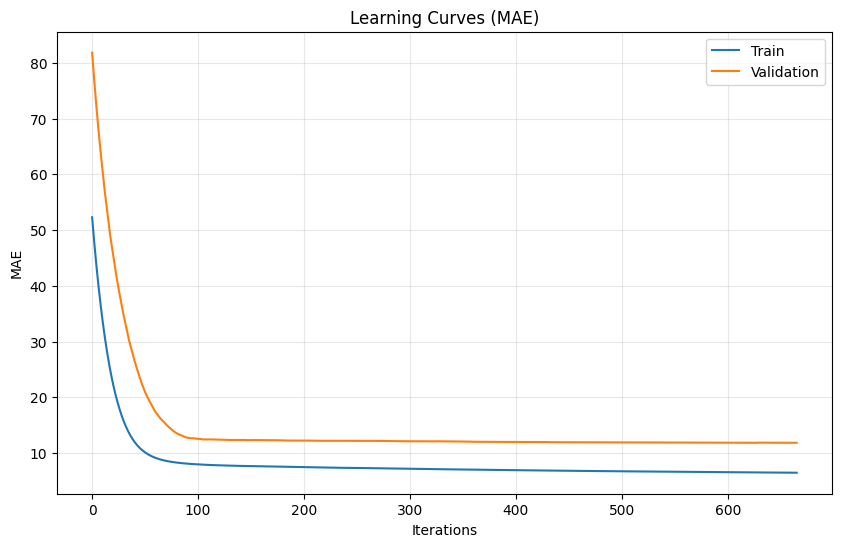

In [48]:
for train_index, val_index in tscv.split(X_np):
    X_train, X_val = X_np[train_index], X_np[val_index]
    y_train, y_val = y_np[train_index], y_np[val_index]

model = lgb.LGBMRegressor(
    **final_params_bstg,
    importance_type='gain'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Train', 'Validation'],
    eval_metric='mae',
    callbacks=[lgb.log_evaluation(period=100), lgb.early_stopping(stopping_rounds=50)]
)

results = model.evals_result_
epochs = range(len(results['Train']['l1']))

plt.figure(figsize=(10, 6))
plt.plot(epochs, results['Train']['l1'], label='Train')
plt.plot(epochs, results['Validation']['l1'], label='Validation')
plt.title('Learning Curves (MAE)')
plt.xlabel('Iterations')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

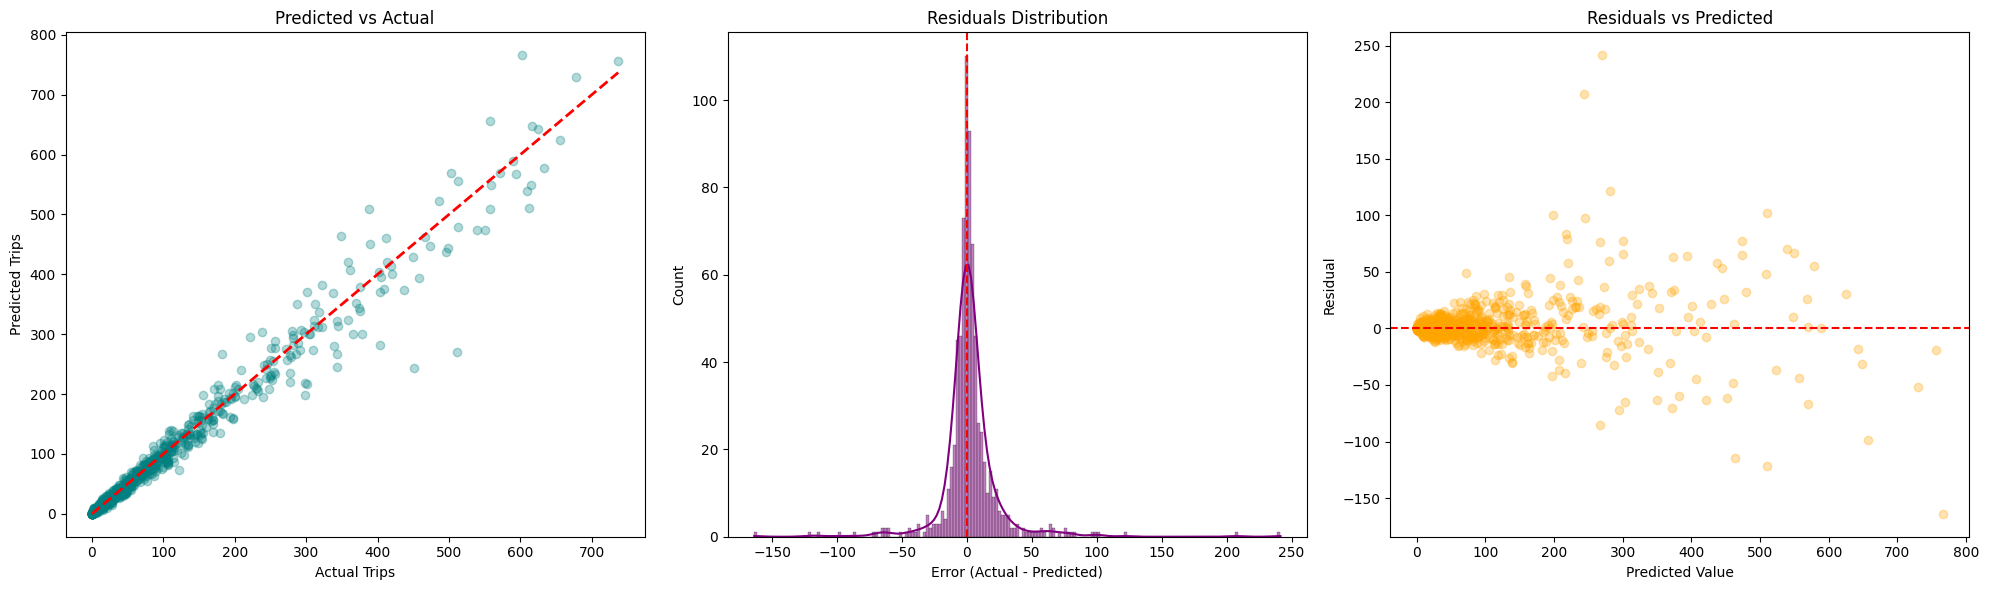

Validation sMAPE: 20.35%


In [49]:
y_pred = model.predict(X_val)
residuals = y_val - y_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(y_val, y_pred, alpha=0.3, color='teal')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual Trips')
axes[0].set_ylabel('Predicted Trips')

sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')

axes[2].scatter(y_pred, residuals, alpha=0.3, color='orange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Predicted')
axes[2].set_xlabel('Predicted Value')
axes[2].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## Алгоритм Random Forest

### Подбор гиперпараметров

In [42]:
rf_enable = True

In [ ]:
def objective(trial):
    param = {
        "boosting_type": "rf",
        "objective": "regression_l1",
        "metric": "mae",
        "n_estimators": 1189,
        "num_leaves": 3759,
        "max_depth": 29,
        "min_child_samples": 247,
        "subsample": 0.9643311966144387,
        "subsample_freq": 1,
        "feature_fraction":  0.47817161713615186,
        "n_jobs": -1,
        "random_state": 42,
        "verbose": -1,
        "device": "gpu"
    }

    scores = []

    for i, (train_idx, val_idx) in enumerate(tscv.split(X_np)):
        X_train, X_val = X_np[train_idx], X_np[val_idx]
        y_train, y_val = y_np[train_idx], y_np[val_idx]

        
        model = lgb.LGBMRegressor(**param)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        mae = mean_absolute_error(y_val, preds)
        scores.append(mae)

        trial.report(mae, i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(scores)

if rf_enable:
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
    )
    study.optimize(objective, n_trials=2)
    print(f"Лучшие параметры: {study.best_params}")

[I 2026-05-06 21:23:15,184] A new study created in memory with name: no-name-19551b1a-0375-48c5-aba1-fc9969144a34


### Визуализация важности гиперпараметров при подборе

In [44]:
if rf_enable:
    vis.plot_param_importances(study)

ValueError: Cannot evaluate parameter importances with only a single trial.

In [50]:
final_params_rf = {
    "boosting_type": "rf",
    "objective": "regression_l1",
    "metric": "mae",
    "n_estimators": 1189,
    "num_leaves": 3759,
    "max_depth": 29,
    "min_child_samples": 247,
    "subsample": 0.9643311966144387,
    "subsample_freq": 1,
    "feature_fraction":  0.47817161713615186,
    "n_jobs": -1,
    "random_state": 42,
    "verbose": -1,
}

[100]	Train's l1: 13.8665	Validation's l1: 31.0588
[200]	Train's l1: 14.0215	Validation's l1: 31.2092
[300]	Train's l1: 14.0442	Validation's l1: 31.3722
[400]	Train's l1: 14.0835	Validation's l1: 31.4646
[500]	Train's l1: 14.0409	Validation's l1: 31.3094
[600]	Train's l1: 13.9878	Validation's l1: 31.0174
[700]	Train's l1: 13.9628	Validation's l1: 30.9686
[800]	Train's l1: 13.9553	Validation's l1: 31.0555
[900]	Train's l1: 13.9806	Validation's l1: 31.0757
[1000]	Train's l1: 13.9633	Validation's l1: 31.0355
[1100]	Train's l1: 13.9705	Validation's l1: 31.051


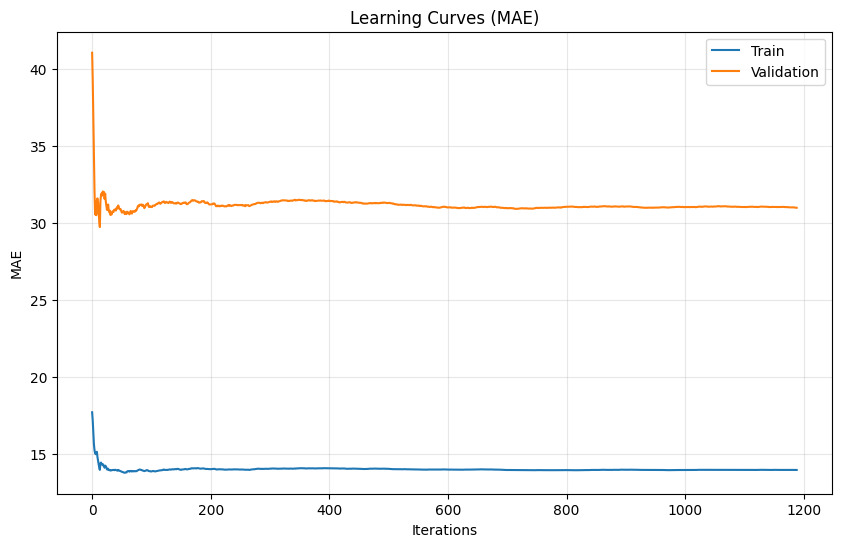

In [52]:
for train_index, val_index in tscv.split(X_np):
    X_train, X_val = X_np[train_index], X_np[val_index]
    y_train, y_val = y_np[train_index], y_np[val_index]

model = lgb.LGBMRegressor(
    **final_params_rf,
    importance_type='gain'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Train', 'Validation'],
    eval_metric='mae',
    callbacks=[lgb.log_evaluation(period=100)]
)

results = model.evals_result_
epochs = range(len(results['Train']['l1']))

plt.figure(figsize=(10, 6))
plt.plot(epochs, results['Train']['l1'], label='Train')
plt.plot(epochs, results['Validation']['l1'], label='Validation')
plt.title('Learning Curves (MAE)')
plt.xlabel('Iterations')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

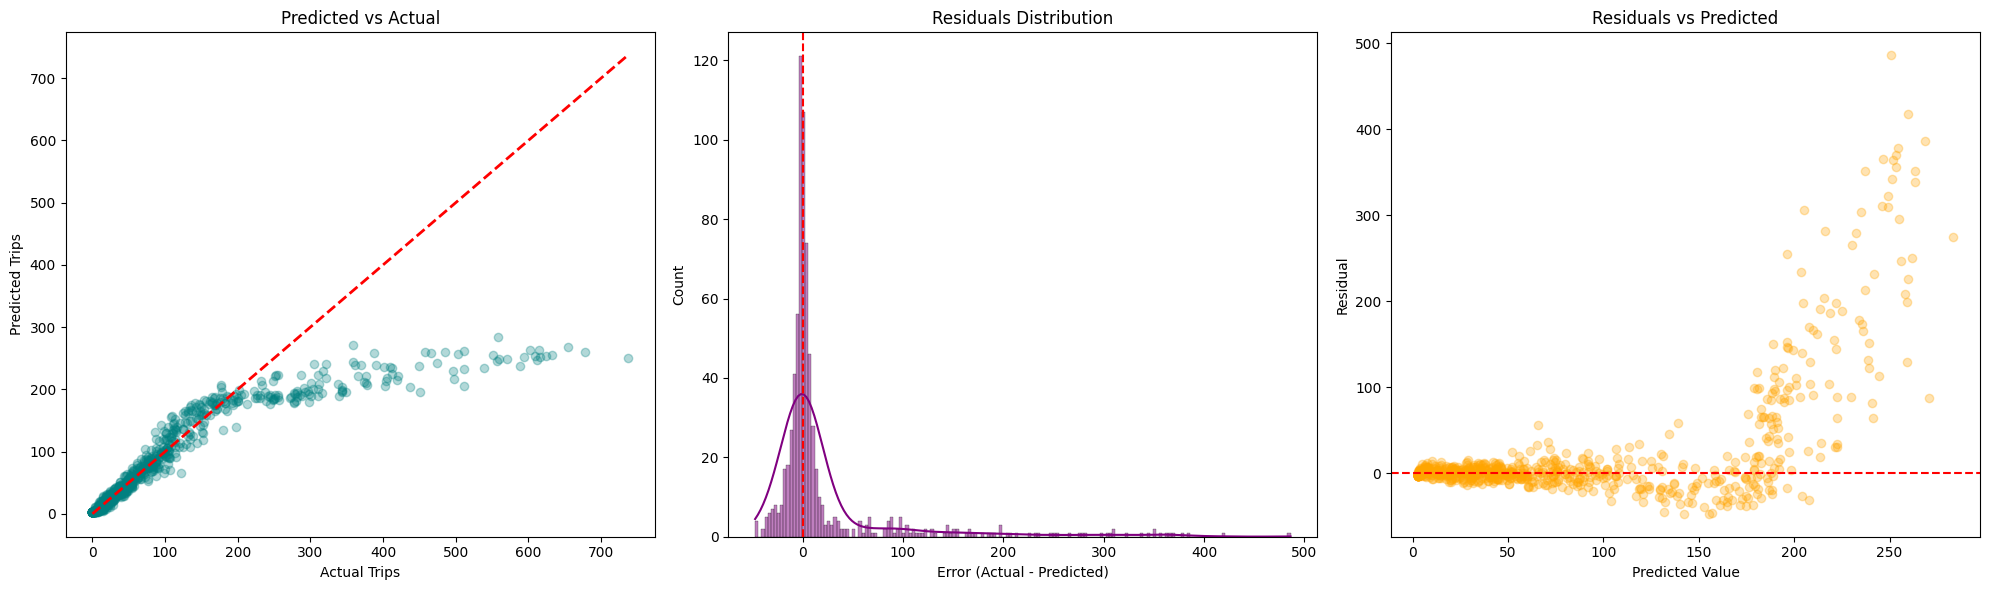

In [53]:
y_pred = model.predict(X_val)
residuals = y_val - y_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(y_val, y_pred, alpha=0.3, color='teal')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual Trips')
axes[0].set_ylabel('Predicted Trips')

sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')

axes[2].scatter(y_pred, residuals, alpha=0.3, color='orange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Predicted')
axes[2].set_xlabel('Predicted Value')
axes[2].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## LSTM

### Обучение модели

In [35]:
lstm_enable = True

In [36]:
from sklearn.preprocessing import RobustScaler

# --- колонки ---
meteodata_columns = [
    'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'snow', 'snowdepth', 'windgust','windspeed', 'winddir',
    'sealevelpressure', 'cloudcover', 'visibility', 'uvindex'
]

numeric_columns = [
    "trips_lag_1h", "trips_lag_day", "trips_lag_week",
    "roll_mean_24h", "roll_std_24h", "roll_mean_week"
]

columns_to_scale = [
    col for col in (meteodata_columns + numeric_columns)
    if col not in features_to_drop
]

# --- split ---
split_idx = int(len(X_df) * 0.8)

X_train = X_df.iloc[:split_idx].copy()
X_val   = X_df.iloc[split_idx:].copy()
y_train = y_np[:split_idx]
y_val   = y_np[split_idx:]

# --- scaler ---
scaler = RobustScaler()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_val[columns_to_scale]   = scaler.transform(X_val[columns_to_scale])


X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)

y_train_np = y_train.astype(np.float32)
y_val_np   = y_val.astype(np.float32)

In [37]:
class TaxiHybridDataset(Dataset):
    def __init__(self, X, y, window_size=12):
        self.window_size = window_size

        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)

        X_seq = []
        X_static = []
        y_out = []

        for i in range(len(X) - window_size):
            X_seq.append(X[i:i + window_size])
            X_static.append(X[i + window_size - 1])
            y_out.append(y[i + window_size - 1])

        self.X_seq = torch.tensor(np.array(X_seq), dtype=torch.float32)
        self.X_static = torch.tensor(np.array(X_static), dtype=torch.float32)
        self.y = torch.tensor(np.array(y_out), dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

In [38]:
class TaxiHybridModel(nn.Module):
    def __init__(self, input_size, static_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Вход в финальный слой: выход LSTM + все статические признаки (вкл. лаги)
        self.fc = nn.Linear(hidden_size + static_size, 64)
        self.out = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, seq, static):
        lstm_out, _ = self.lstm(seq)
        last_hidden = lstm_out[:, -1, :] # Берем состояние последнего часа
        
        # Склеиваем "динамику" из LSTM и "факты" (лаги за день/неделю)
        combined = torch.cat((last_hidden, static), dim=1)
        
        x = self.relu(self.fc(combined))
        return self.out(x)

In [39]:
def objective(trial):

    device = torch.device("cuda")

    # --- HYPERPARAMS ---
    win_size = trial.suggest_int("window_size", 6, 24)
    hidden_size = trial.suggest_int("hidden_size", 64, 256)
    num_layers = trial.suggest_int("num_layers", 1, 2)
    lr = trial.suggest_float("lr", 1e-4, 5e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [512, 1024, 2048])

    # --- DATA ---
    train_ds = TaxiHybridDataset(X_train_np, y_train_np, window_size=win_size)
    val_ds   = TaxiHybridDataset(X_val_np, y_val_np, window_size=win_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # --- MODEL ---
    model = TaxiHybridModel(
        input_size=X_train.shape[1],
        static_size=X_train.shape[1],
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=0.2
    ).to(device)

    if torch.cuda.device_count() > 1:
        model = torch.nn.DataParallel(model)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    # --- EARLY STOPPING ---
    best_val = float("inf")
    patience = 3
    counter = 0

    for epoch in range(20):

        # ===== TRAIN =====
        model.train()
        for seq, static, target in train_loader:
            seq = seq.to(device)
            static = static.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = model(seq, static)
            loss = criterion(output.squeeze(), target)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

        # ===== VALIDATION =====
        model.eval()
        val_losses = []
        
        with torch.no_grad():
            for seq, static, target in val_loader:
                seq = seq.to(device)
                static = static.to(device)
                target = target.to(device)
        
                output = model(seq, static)
        
                loss = criterion(output.squeeze(), target)
                val_losses.append(loss.item())
        
        val_mae = np.mean(val_losses)
        print(f"Epoch {epoch} | Val MAE: {val_mae}")

        # ===== EARLY STOPPING =====
        if val_mae < best_val:
            best_val = val_mae
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    return best_val

In [40]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)
print("Best MAE:", study.best_value)

[I 2026-05-06 18:40:17,175] A new study created in memory with name: no-name-5788b52b-d590-479a-ad96-1a711e8cb899


Epoch 0 | Val MAE: 20.783502552588438
Epoch 1 | Val MAE: 15.326556508503263
Epoch 2 | Val MAE: 13.643918414480586
Epoch 3 | Val MAE: 13.148645811782771
Epoch 4 | Val MAE: 12.794395963522952
Epoch 5 | Val MAE: 12.46940995157195
Epoch 6 | Val MAE: 12.464724622591577
Epoch 7 | Val MAE: 12.20516196370641
Epoch 8 | Val MAE: 12.12794132081289
Epoch 9 | Val MAE: 12.071361303673505
Epoch 10 | Val MAE: 12.126805338508639
Epoch 11 | Val MAE: 12.111171630897907
Epoch 12 | Val MAE: 12.118401797818931


[I 2026-05-06 18:59:27,092] Trial 0 finished with value: 12.071361303673505 and parameters: {'window_size': 16, 'hidden_size': 175, 'num_layers': 2, 'lr': 0.00013335703679987604, 'batch_size': 512}. Best is trial 0 with value: 12.071361303673505.


Epoch 0 | Val MAE: 20.935199026077512
Epoch 1 | Val MAE: 13.972588436600105
Epoch 2 | Val MAE: 13.139679703705582
Epoch 3 | Val MAE: 13.033669861880215
Epoch 4 | Val MAE: 13.032144755684108
Epoch 5 | Val MAE: 12.666036868680264
Epoch 6 | Val MAE: 12.64621539136548
Epoch 7 | Val MAE: 12.482987458915765
Epoch 8 | Val MAE: 12.528708646479796
Epoch 9 | Val MAE: 12.435071742207802
Epoch 10 | Val MAE: 12.342833163246276
Epoch 11 | Val MAE: 12.244448974191025
Epoch 12 | Val MAE: 12.170019952077714
Epoch 13 | Val MAE: 12.148549969578202
Epoch 14 | Val MAE: 12.066621970304679
Epoch 15 | Val MAE: 12.007073050797588
Epoch 16 | Val MAE: 12.115495932910694
Epoch 17 | Val MAE: 12.060426278547807


[I 2026-05-06 19:12:39,353] Trial 1 finished with value: 12.007073050797588 and parameters: {'window_size': 16, 'hidden_size': 236, 'num_layers': 1, 'lr': 0.0001376420202128834, 'batch_size': 512}. Best is trial 1 with value: 12.007073050797588.


...

Epoch 17 | Val MAE: 11.900473951089262
Epoch 0 | Val MAE: 16.283047543975698
Epoch 1 | Val MAE: 13.264355871412489
Epoch 2 | Val MAE: 12.714055530608647
Epoch 3 | Val MAE: 12.610259863893363
Epoch 4 | Val MAE: 12.477218303845559
Epoch 5 | Val MAE: 12.317354384610836
Epoch 6 | Val MAE: 12.23642670230948
Epoch 7 | Val MAE: 12.205144851238696
Epoch 8 | Val MAE: 12.445216786465776
Epoch 9 | Val MAE: 12.063196412068597
Epoch 10 | Val MAE: 12.079428164989917
Epoch 11 | Val MAE: 12.223308424240926
Epoch 12 | Val MAE: 11.981341335852596
Epoch 13 | Val MAE: 11.915278295761922
Epoch 14 | Val MAE: 11.991576807151453
Epoch 15 | Val MAE: 11.835965936834162
Epoch 16 | Val MAE: 12.05855673009699
Epoch 17 | Val MAE: 11.883691244827205


[I 2026-05-06 19:49:53,221] Trial 4 finished with value: 11.835965936834162 and parameters: {'window_size': 10, 'hidden_size': 97, 'num_layers': 1, 'lr': 0.0002599860775023297, 'batch_size': 512}. Best is trial 2 with value: 11.519967308649068.


Epoch 18 | Val MAE: 12.098731073294195
Epoch 0 | Val MAE: 20.201712393966808


[W 2026-05-06 19:50:46,786] Trial 5 failed with parameters: {'window_size': 12, 'hidden_size': 202, 'num_layers': 2, 'lr': 0.00022025679521801115, 'batch_size': 1024} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_57/1584920399.py", line 53, in objective
    loss.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 630, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 364, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py", line 865, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
           ^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

# Оценка построенных моделей на отложенной выборке

In [23]:
def compute_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def compute_smape(y_true, y_pred):
    numerator = 2 * np.abs(y_true - y_pred)
    denominator = np.abs(y_true) + np.abs(y_pred)
    smape = np.where(denominator == 0, 0, numerator / denominator)
    return 100 * np.mean(smape)


## LightGBM обучение и оценка

In [25]:
print("="*80)
print("LIGHTGBM - ОБУЧЕНИЕ С КРОСС-ВАЛИДАЦИЕЙ")
print("="*80)

X_df_clean = pd.DataFrame(X_np, columns=features)

X_np_clean = X_df_clean.values
y_np_clean = y_np

test_features = test.select(features).to_pandas()
test_features = test_features.drop(columns=features_to_drop)
X_test = test_features.values
y_test = test.select(target).to_pandas().values.ravel()

tscv_final = TimeSeriesSplit(n_splits=3, test_size=24*31)

lgbm_cv_preds = []
lgbm_cv_indices = []
lgbm_cv_maes = []
lgbm_models = []

for fold, (train_idx, val_idx) in enumerate(tscv_final.split(X_np_clean), start=1):
    X_train_fold, X_val_fold = X_np_clean[train_idx], X_np_clean[val_idx]
    y_train_fold, y_val_fold = y_np_clean[train_idx], y_np_clean[val_idx]

    print(f"\nFold {fold}:")
    print(f"  Train size: {len(train_idx)}, Val size: {len(val_idx)}")

    lgbm_model = lgb.LGBMRegressor(**final_params_bstg)
    lgbm_model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0)
        ]
    )

    preds_val = lgbm_model.predict(X_val_fold)
    mae = mean_absolute_error(y_val_fold, preds_val)

    lgbm_cv_preds.append(preds_val)
    lgbm_cv_indices.append(val_idx)
    lgbm_cv_maes.append(mae)
    lgbm_models.append(lgbm_model)

    print(f"  Val MAE: {mae:.4f}")

print(f"\nСредний MAE на кросс-валидации: {np.mean(lgbm_cv_maes):.4f}")
print(f"Std MAE на кросс-валидации: {np.std(lgbm_cv_maes):.4f}")

test_df = test.to_pandas().sort_values(["hour_bucket", "PULocationID"]).reset_index(drop=True)
hist_df = train_cv.to_pandas().sort_values(["hour_bucket", "PULocationID"]).reset_index(drop=True)

test_df['hour_bucket'] = pd.to_datetime(test_df['hour_bucket'])
hist_df['hour_bucket'] = pd.to_datetime(hist_df['hour_bucket'])

unique_times = test_df['hour_bucket'].sort_values().unique()

lgbm_direct_model = lgb.LGBMRegressor(**final_params_bstg)
lgbm_direct_model.fit(X_np_clean, y_np_clean, callbacks=[lgb.log_evaluation(period=0)])

def make_features_for_time(t, hist_df, test_rows):
    rows = []
    for _, row in test_rows.iterrows():
        loc = row['PULocationID']
        month = t.month
        day = t.day
        dayofweek = t.weekday()
        hour = t.hour
        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)

        def get_hist_value(delta_hours):
            ts = t - pd.Timedelta(hours=delta_hours)
            v = hist_df.loc[(hist_df['PULocationID']==loc) & (hist_df['hour_bucket']==ts), 'trips_count']
            return float(v.iloc[0]) if not v.empty else 0.0

        trips_lag_1h = get_hist_value(1)
        trips_lag_day = get_hist_value(24)
        trips_lag_week = get_hist_value(24*7)

        # rolling stats (past 24h and 7d)
        past_24_start = t - pd.Timedelta(hours=24)
        mask24 = (hist_df['PULocationID']==loc) & (hist_df['hour_bucket']>past_24_start) & (hist_df['hour_bucket']<t)
        past24 = hist_df.loc[mask24, 'trips_count']
        roll_mean_24h = float(past24.mean()) if len(past24)>0 else 0.0
        roll_std_24h = float(past24.std()) if len(past24)>0 else 0.0

        past_week_start = t - pd.Timedelta(hours=24*7)
        mask7 = (hist_df['PULocationID']==loc) & (hist_df['hour_bucket']>past_week_start) & (hist_df['hour_bucket']<t)
        pastweek = hist_df.loc[mask7, 'trips_count']
        roll_mean_week = float(pastweek.mean()) if len(pastweek)>0 else 0.0

        # zone_avg_trips (causal): mean over history for the zone
        z = hist_df.loc[hist_df['PULocationID']==loc, 'trips_count']
        zone_avg_trips = float(z.mean()) if len(z)>0 else hist_df['trips_count'].mean()

        # meteorological and other static features from test row (actual known)
        temp = row.get('temp', 0.0)
        precip = row.get('precip', 0.0)
        precipprob = row.get('precipprob', 0.0)
        snow = row.get('snow', 0.0)
        snowdepth = row.get('snowdepth', 0.0)
        windgust = row.get('windgust', 0.0)
        windspeed = row.get('windspeed', 0.0)
        winddir = row.get('winddir', 0.0)
        sealevelpressure = row.get('sealevelpressure', 0.0)
        cloudcover = row.get('cloudcover', 0.0)
        visibility = row.get('visibility', 0.0)
        uvindex = row.get('uvindex', 0.0)
        is_rain = row.get('is_rain', 0)
        is_snow = row.get('is_snow', 0)

        feat = {
            'PULocationID': loc,
            'zone_avg_trips': zone_avg_trips,
            'month': month,
            'day': day,
            'dayofweek': dayofweek,
            'hour_sin': hour_sin,
            'hour_cos': hour_cos,
            'trips_lag_1h': trips_lag_1h,
            'trips_lag_day': trips_lag_day,
            'trips_lag_week': trips_lag_week,
            'roll_mean_24h': roll_mean_24h,
            'roll_std_24h': roll_std_24h,
            'roll_mean_week': roll_mean_week,
            'temp': temp,
            'precip': precip,
            'precipprob': precipprob,
            'snow': snow,
            'snowdepth': snowdepth,
            'windgust': windgust,
            'windspeed': windspeed,
            'winddir': winddir,
            'sealevelpressure': sealevelpressure,
            'cloudcover': cloudcover,
            'visibility': visibility,
            'uvindex': uvindex,
            'is_rain': is_rain,
            'is_snow': is_snow,
        }
        rows.append(feat)
    return pd.DataFrame(rows)

# Now iteratively forecast across test period
lgbm_preds_list = []
for t in unique_times:
    test_rows_t = test_df[test_df['hour_bucket']==t]
    X_t = make_features_for_time(t, hist_df, test_rows_t)
    # re-order columns to match training features
    X_t = X_t[features]
    preds_t = lgbm_direct_model.predict(X_t)
    lgbm_preds_list.append(pd.DataFrame({
        'hour_bucket': t,
        'PULocationID': test_rows_t['PULocationID'].values,
        'trips_count': preds_t
    }))
    # append predicted rows to history for next iterations
    append_df = pd.DataFrame({
        'hour_bucket': [t]*len(preds_t),
        'PULocationID': test_rows_t['PULocationID'].values,
        'trips_count': preds_t
    })
    hist_df = pd.concat([hist_df, append_df], ignore_index=True)

lgbm_preds_df = pd.concat(lgbm_preds_list, ignore_index=True)
# Align predictions to test_df order
lgbm_test_preds = test_df.merge(lgbm_preds_df, on=['hour_bucket','PULocationID'])['trips_count_y'].values
print(f"\nRecursive predictions for LightGBM done (size: {len(lgbm_test_preds)})")


LIGHTGBM - ОБУЧЕНИЕ С КРОСС-ВАЛИДАЦИЕЙ


KeyError: "['precipprob', 'is_snow', 'is_rain', 'snow', 'feelslike', 'snowdepth'] not found in axis"

## Random Forest обучение и оценка

In [ ]:
print("\n" + "="*80)
print("RANDOM FOREST - ОБУЧЕНИЕ С КРОСС-ВАЛИДАЦИЕЙ")
print("="*80)

rf_cv_preds = []
rf_cv_indices = []
rf_cv_maes = []
rf_models = []

for fold, (train_idx, val_idx) in enumerate(tscv_final.split(X_np_clean), start=1):
    X_train_fold, X_val_fold = X_np_clean[train_idx], X_np_clean[val_idx]
    y_train_fold, y_val_fold = y_np_clean[train_idx], y_np_clean[val_idx]

    print(f"\nFold {fold}:")
    print(f"  Train size: {len(train_idx)}, Val size: {len(val_idx)}")

    rf_model = lgb.LGBMRegressor(**final_params_rf)
    rf_model.fit(
        X_train_fold, y_train_fold,
        callbacks=[lgb.log_evaluation(period=0)]
    )

    preds_val = rf_model.predict(X_val_fold)
    mae = mean_absolute_error(y_val_fold, preds_val)

    rf_cv_preds.append(preds_val)
    rf_cv_indices.append(val_idx)
    rf_cv_maes.append(mae)
    rf_models.append(rf_model)

    print(f"  Val MAE: {mae:.4f}")

print(f"\nСредний MAE на кросс-валидации: {np.mean(rf_cv_maes):.4f}")
print(f"Std MAE на кросс-валидации: {np.std(rf_cv_maes):.4f}")


## Train final RF and run recursive forecasting on holdout
rf_direct_model = lgb.LGBMRegressor(**final_params_rf)
rf_direct_model.fit(X_np_clean, y_np_clean, callbacks=[lgb.log_evaluation(period=0)])

# Use separate history for RF recursion
hist_df_rf = train_cv.to_pandas().sort_values(["hour_bucket", "PULocationID"]).reset_index(drop=True)
hist_df_rf['hour_bucket'] = pd.to_datetime(hist_df_rf['hour_bucket'])

rf_preds_list = []
for t in unique_times:
    test_rows_t = test_df[test_df['hour_bucket']==t]
    X_t = make_features_for_time(t, hist_df_rf, test_rows_t)
    X_t = X_t[features]
    preds_t = rf_direct_model.predict(X_t)
    rf_preds_list.append(pd.DataFrame({
        'hour_bucket': t,
        'PULocationID': test_rows_t['PULocationID'].values,
        'trips_count': preds_t
    }))
    append_df = pd.DataFrame({
        'hour_bucket': [t]*len(preds_t),
        'PULocationID': test_rows_t['PULocationID'].values,
        'trips_count': preds_t
    })
    hist_df_rf = pd.concat([hist_df_rf, append_df], ignore_index=True)

rf_preds_df = pd.concat(rf_preds_list, ignore_index=True)
rf_test_preds = test_df.merge(rf_preds_df, on=['hour_bucket','PULocationID'])['trips_count_y'].values
print(f"\nRecursive predictions for RF done (size: {len(rf_test_preds)})")


## Сравнение моделей на отложенной выборке

In [ ]:
print("\n" + "="*80)
print("СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*80)

lgbm_mae = compute_mae(y_test, lgbm_test_preds)
lgbm_rmse = compute_rmse(y_test, lgbm_test_preds)
lgbm_smape = compute_smape(y_test, lgbm_test_preds)

rf_mae = compute_mae(y_test, rf_test_preds)
rf_rmse = compute_rmse(y_test, rf_test_preds)
rf_smape = compute_smape(y_test, rf_test_preds)

results_df = pd.DataFrame({
    'Метрика': ['MAE', 'RMSE', 'sMAPE (%)'],
    'LightGBM': [f'{lgbm_mae:.4f}', f'{lgbm_rmse:.4f}', f'{lgbm_smape:.2f}%'],
    'Random Forest': [f'{rf_mae:.4f}', f'{rf_rmse:.4f}', f'{rf_smape:.2f}%']
})

print("\nРЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (Test: {} записей)".format(len(y_test)))
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("ДЕТАЛЬНАЯ СТАТИСТИКА")
print("="*80)

print("\nLightGBM:")
print(f"  MAE:   {lgbm_mae:.6f}")
print(f"  RMSE:  {lgbm_rmse:.6f}")
print(f"  sMAPE: {lgbm_smape:.4f}%")

print("\nRandom Forest:")
print(f"  MAE:   {rf_mae:.6f}")
print(f"  RMSE:  {rf_rmse:.6f}")
print(f"  sMAPE: {rf_smape:.4f}%")

print("\n" + "="*80)
print("ИТОГИ")
print("="*80)

best_model_mae = "LightGBM" if lgbm_mae < rf_mae else "Random Forest"
best_model_rmse = "LightGBM" if lgbm_rmse < rf_rmse else "Random Forest"
best_model_smape = "LightGBM" if lgbm_smape < rf_smape else "Random Forest"

print(f"\nЛучшая модель по MAE: {best_model_mae}")
print(f"Лучшая модель по RMSE: {best_model_rmse}")
print(f"Лучшая модель по sMAPE: {best_model_smape}")

improvement_mae = ((rf_mae - lgbm_mae) / rf_mae * 100) if rf_mae > lgbm_mae else ((lgbm_mae - rf_mae) / lgbm_mae * 100)
print(f"\nРазница MAE: {abs(improvement_mae):.2f}% в пользу {best_model_mae}")


## Визуализация результатов

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(y_test, lgbm_test_preds, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title(f'LightGBM\nMAE={lgbm_mae:.4f}, RMSE={lgbm_rmse:.4f}, sMAPE={lgbm_smape:.2f}%')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, rf_test_preds, alpha=0.3, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Фактические значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].set_title(f'Random Forest\nMAE={rf_mae:.4f}, RMSE={rf_rmse:.4f}, sMAPE={rf_smape:.2f}%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lgbm_residuals = y_test - lgbm_test_preds
rf_residuals = y_test - rf_test_preds

axes[0].hist(lgbm_residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Остатки')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'LightGBM - Распределение остатков\nСреду остатков: {np.mean(lgbm_residuals):.4f}')
axes[0].grid(True, alpha=0.3)

axes[1].hist(rf_residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Остатки')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Random Forest - Распределение остатков\nСреду остатков: {np.mean(rf_residuals):.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Анализ ошибок модели